In [1]:
from dataclasses import replace
from pathlib import Path

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from musiq.pulse.sequence import PulseCompiler
from musiq.workflow import create_model


MODEL_DIR = Path(".")
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
CIRC_DIR = MODEL_DIR / "circuits"
CIRC_DIR.mkdir(exist_ok=True)

In [2]:
def activate_qubits(model, qubit_ids):
    qubit_ids = set(qubit_ids)
    ordered_qubits = sorted(qubit_ids)
    active_connections = []
    for device_key in list(model.config.devices.keys()):
        device_cfg = model.config.devices[device_key].device
        if not active_connections:
            active_connections = [
                conn['id'] for conn in device_cfg['connections']
                if conn['a'] in qubit_ids and conn['b'] in qubit_ids
            ]
    for solver_cfg in model.config.solvers.values():
        for study in solver_cfg.study:
            study['active_components'] = ordered_qubits
            study['active_connections'] = active_connections
            study['representations'] = {qid: 'quantum' for qid in ordered_qubits}
            study['bases'] = {qid: {'kind': 'nlevel', 'levels': 2} for qid in ordered_qubits}
    return model

## Calibration

In [3]:
from scipy.optimize import minimize

model = create_model(
    circuits=MODEL_DIR / "circuit_sx.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser_sweep.yaml",
)
model = activate_qubits(model, {'q0'})

def loss(model, amplitude_hz: float):
    model_run = model.copy(include_results=False)
    model_run.config.pulses["default"].extras["gates"]["sx"]["amplitude_Hz"] = float(amplitude_hz)
    model_run.run_all()

    metrics = model_run.analyses["case_0"].metrics
    p0 = float(metrics["population"].values['0'][-1])
    p1 = float(metrics["population"].values['1'][-1])
    return (p0 - 0.5) ** 2 + (p1 - 0.5) ** 2

def objective(x):
    return loss(model, float(x[0]))

res_nm = minimize(
    objective,
    x0=np.array([8.0e6], dtype=float),
    method="Nelder-Mead",
    options={
        "xatol": 1.0e3,
        "fatol": 1.0e-8,
        "maxiter": 50,
        "disp": True,
    },
)

best_sx_amp = float(res_nm.x[0])
print("The best amplitude of SX gate (Hz) = {}".format(best_sx_amp))

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 11
         Function evaluations: 22
The best amplitude of SX gate (Hz) = 8862500.0


In [4]:

model = create_model(
    circuits=MODEL_DIR / "circuit_bell.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser_sweep.yaml",
)
model = activate_qubits(model, {'q0', 'q1'})

def loss(model, amplitude_hz: float):
    model_run = model.copy(include_results=False)
    model_run.config.pulses["default"].extras["gates"]["cz"]["amplitude_Hz"] = float(amplitude_hz)
    model_run.run_all()

    metrics = model_run.analyses["case_0"].metrics
    p00 = float(metrics["population"].values['00'][-1])
    p11 = float(metrics["population"].values['11'][-1])
    return (p00 - 0.5) ** 2 + (p11 - 0.5) ** 2

def objective(x):
    return loss(model, float(x[0]))

res_nm = minimize(
    objective,
    x0=np.array([10.0e6], dtype=float),
    method="Nelder-Mead",
    options={
        "xatol": 1.0e3,
        "fatol": 1.0e-8,
        "maxiter": 50,
        "disp": True,
    },
)

best_cz_amp = float(res_nm.x[0])
print("The best amplitude of CZ gate (Hz) = {}".format(best_cz_amp))

Optimization terminated successfully.
         Current function value: 0.000607
         Iterations: 10
         Function evaluations: 20
The best amplitude of CZ gate (Hz) = 10416992.1875


## Test small circuits

In [5]:
from pathlib import Path

def get_json_files(folder_path):
    path = Path(folder_path)
    json_files = [file.name[:-5] for file in path.glob("*.json")]
    return json_files

circuit_files = get_json_files(CIRC_DIR)

for i, file in enumerate(circuit_files):
    print(f"[{i}] {file}")

[0] basis_change_n3_transpiled
[1] basis_trotter_n4_transpiled
[2] bell_n4_transpiled
[3] dnn_n8_transpiled
[4] ising_n10_transpiled
[5] qaoa_n3_transpiled
[6] qaoa_n6_transpiled
[7] variational_n4_transpiled
[8] vqe_uccsd_n4_transpiled


In [12]:
circuit_name = circuit_files[6]

In [ ]:
from musiq.workflow import CircuitConfig

circuit_cfg = CircuitConfig.from_schedule_file(CIRC_DIR  / f"{circuit_name}.yaml")

model = create_model(
    circuits = circuit_cfg,
    devices = {
        "ideal": MODEL_DIR / "device_ideal.yaml",
        "noise": MODEL_DIR / "device.yaml",
    },
    pulses = MODEL_DIR / "pulse.yaml",
    solvers = MODEL_DIR / "solver.yaml",
    analysers = MODEL_DIR / "analyser.yaml",
)

model = activate_qubits(model, {f'q{i}' for i in range(model.circuit.circuit_ir.num_qubits)})
model.config.pulses['default'].extras['gates']['sx']['amplitude_Hz'] = best_sx_amp
model.config.pulses['default'].extras['gates']['cz']['amplitude_Hz'] = best_cz_amp

model.run_all()

ideal_pop = model.analyses['case_0'].metrics['population']
noise_pop = model.analyses['case_1'].metrics['population']

fig, ax = plt.subplots(figsize=(8, 3))
for k, v in ideal_pop.values.items():
    ax.plot(np.asarray(ideal_pop.times) * 1e9, v, label=f"ideal {k}")
for k, v in noise_pop.values.items():
    ax.plot(np.asarray(noise_pop.times) * 1e9, v, label=f"noise {k}", linestyle="dashed")

ax.set_xlabel("time (ns)")
ax.set_ylabel("population")
ax.set_title(f"Population evolution for {circuit_name}")
# ax.legend(ncol=2)
plt.savefig(FIG_DIR / f"{circuit_name}_population.png", dpi=600, bbox_inches='tight')

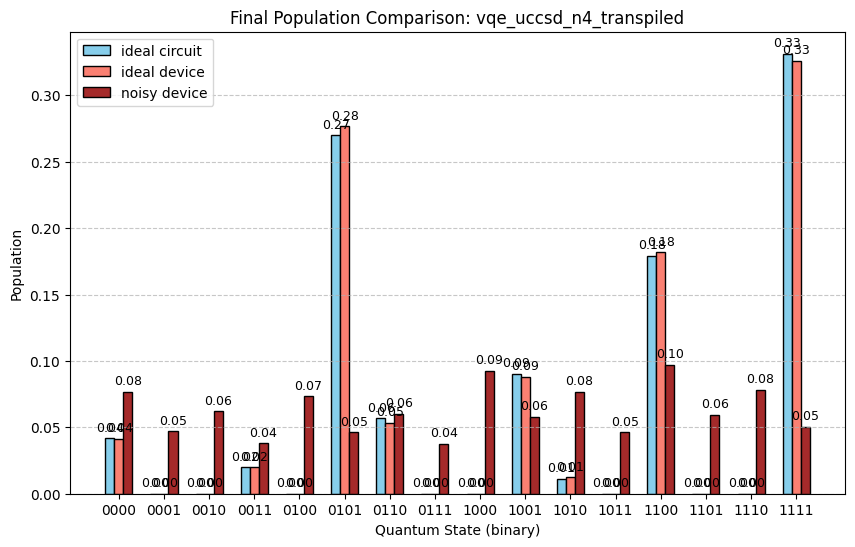

In [ ]:
import matplotlib.pyplot as plt 
import json

with open(CIRC_DIR / f"{circuit_name}.json", 'r', encoding='utf-8') as f:
    data = json.load(f)

ref_pop = data['probabilities']

# 1. 确保 X 轴标签一致且有序（按二进制字符串排序）
labels = sorted(ideal_pop.values.keys())
values1 = [ref_pop[k] for k in labels]
values2 = [ideal_pop.values[k][-1] for k in labels]
values3 = [noise_pop.values[k][-1] for k in labels]

# 2. 设置柱状图的位置
x = np.arange(len(labels))  # 标签位置 [0, 1, ..., 7]
width = 0.2               # 柱子宽度

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制两组柱状图
rects1 = ax.bar(x - width, values1, width, label='ideal circuit', color='skyblue', edgecolor='black')
rects2 = ax.bar(x , values2, width, label='ideal device', color='salmon', edgecolor='black')
rects3 = ax.bar(x + width, values3, width, label='noisy device', color='brown', edgecolor='black')

# 3. 添加装饰
ax.set_ylabel('Population')
ax.set_xlabel('Quantum State (binary)')
ax.set_title(f'Final Population Comparison: {circuit_name}')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 可选：在柱子顶部添加数值标注
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3pts vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# fig.tight_layout()
# plt.show()
plt.savefig(FIG_DIR / f"{circuit_name}_comparison.png", dpi=600, bbox_inches='tight')

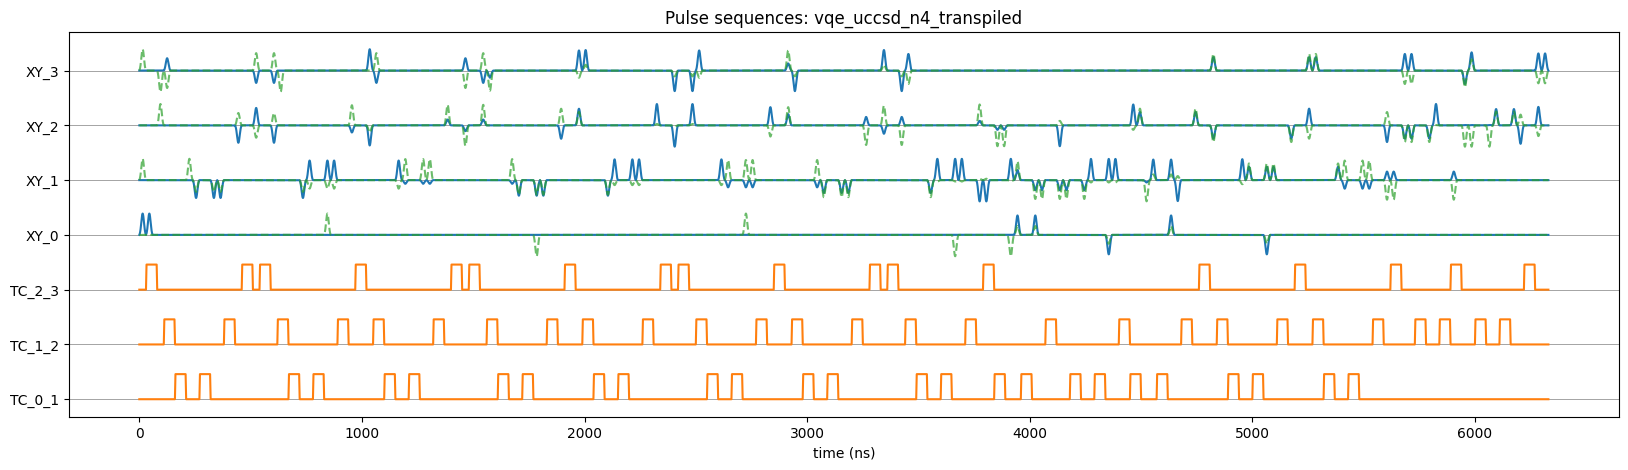

In [ ]:
pulse_ir = model.runs['solver_0']['pulse_shape'].artifacts.pulse_ir
pulse_samples = PulseCompiler.compile(pulse_ir, sample_rate_Hz=5e10)

fig, ax = plt.subplots(figsize=(20, 5))

i = 0
yscale = 1.0
for channel, waveform in pulse_samples.items():
    if channel[:2] == "XY": color = ["tab:blue", "tab:green"]
    elif channel[:2] == "TC": color = ["tab:orange", "tab:gold"]
    else: color = ["tab:red"]
    ax.plot(np.asarray(waveform["t"]) * 1e9, waveform["y"]*0.7e-8 + yscale * i, label=channel, color=color[0], linewidth=1.5)
    if "y_quadrature" in waveform:
        ax.plot(np.asarray(waveform["t"]) * 1e9, waveform["y_quadrature"]*0.7e-8 + yscale * i, '--', color=color[1], linewidth=1.5, alpha=0.7)
    i = i + 1
ticklabels = list(pulse_samples.keys())
ax.set_yticks(yscale * np.arange(len(ticklabels)))
ax.grid(color='gray', linestyle='-', linewidth=0.5, axis='y', zorder=0)
ax.set_yticklabels(ticklabels)
ax.set_xlabel("time (ns)")
ax.set_title(f"Pulse sequences: {circuit_name}")
plt.savefig(FIG_DIR / f"{circuit_name}_pulses.png", dpi=600, bbox_inches='tight')